In [1]:
import itertools
import csv

import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate
from torchquad import set_up_backend, Trapezoid, Simpson, MonteCarlo
import torch
from torch import exp, sin, cos

In [2]:
set_up_backend("torch", data_type="float32")
tp = Trapezoid()
device = "cpu"

16:16:49|TQ-WARNING| Error enabling CUDA. cuda.is_available() returned False. CPU will be used.
/Users/ppapac/git/24112024_memoryfn/.venv/lib/python3.9/site-packages/torch/__init__.py:1240: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/tensor/python_tensor.cpp:436.)
  _C._set_default_tensor_type(t)


## Konstante i osnovne funkcije

In [16]:
kb = 8.6173303 * 10 ** (-5)
hbar = 6.582119569 * 10 ** (-16)
pi = np.pi
c = 3 * 10**8
m = 0.511 / c**2 * 10**6
e = 1.602 * 10 ** (-19)

alpha_op = 0.4
alpha_ac = 1
hbar_w_op = torch.Tensor([0.1]).to(device)
eta_0 = 0.5 * 10 ** (-3)
M = 0.0
Kf_20 = 0.2  # eV, Fermi at 20K
vf = 4 * 10**5
a = 100 ** (1 / 3) * 10 ** (-10)
T_0 = 4
T_F = Kf_20 / kb

Kf_ = Kf_20 / hbar / vf * a  # Fermi unitless
Kf_max = 0.8 / hbar / vf * a  # cutoff 1eV unitless
c_s_tilde = 0.03  # hbar_w_ac_max / hbar / vf * a
hbar_w_ac_max = c_s_tilde * hbar * vf / a
G_op2 = alpha_op
G_ac2 = alpha_ac * hbar * vf / a


Ef = torch.sqrt(torch.FloatTensor([Kf_20**2 + M**2])).to(device)

In [4]:
def arrays_to_csv(array1, array2, name):
    with open(f"{name}.csv", "w", newline="") as file:
        writer = csv.writer(file)
        for a1, a2 in zip(array1, array2):
            writer.writerow([round(a1, 5), a2])


def read_from_csv(name):
    col_1 = []
    col_2 = []
    with open(f"{name}.csv", "r", newline="") as file:
        reader = csv.reader(file)
        for a1, a2 in reader:
            col_1.append(float(a1))
            col_2.append(float(a2))
    return col_1, col_2

In [5]:
def fermi_dirac(E, Ef, T):
    if T > 0:
        return torch.where(
            E > Ef,
            exp((-E + Ef) / (kb * T)) / (exp((-E + Ef) / (kb * T)) + 1),
            1 / (exp((E - Ef) / (kb * T)) + 1),
        )
    else:
        return torch.where(E > Ef, 0, 1)


def d_fermi_dirac(E, Ef, T):
    return 1 / kb / T * fermi_dirac(E, Ef, T) * (1 - fermi_dirac(E, Ef, T))


def bose_einstein(E, T):
    if T == 0:
        return 0
    return torch.where(E > 0, exp(-E / (kb * T)) / (-exp(-E / (kb * T)) + 1), 0)


def chemical_potential(T):
    return (
        Ef
        - pi**2 / 6 * (2 * Ef**2 - M**2) / Ef / (Ef**2 - M**2) * (kb * T) ** 2
        - 7 / 360 * pi**4 * 3 * M**4 / Ef / (Ef**2 - M**2) ** 3 * (kb * T) ** 4
    )


def eps(K):
    arg = hbar**2 * vf**2 / a**2 * K**2 + M**2
    if isinstance(K, torch.Tensor):
        return torch.sqrt(arg)
    else:
        return np.sqrt(arg)


def eff_concetration(T):
    def integrand(k):
        return 2 / hbar / vf / a**2 * fermi_dirac(eps(k), Ef, T) * k

    return (
        4
        * pi
        / 3
        * 2
        / (2 * pi) ** 3
        * vf**2
        * integrate.quad(integrand, 0, Kf_max, limit=80000)[0]
    )

In [6]:
print(eff_concetration(40))  # T=0 numerički
print(4 * pi / 3 * 2 / (2 * pi) ** 3 * Kf_20**2 / hbar**3 / vf)  # T=0 analitički

1.185511860363544e+37
1.184354454914293e+37


In [42]:
ws_0 = torch.arange(0, 1, 0.001)



def calculate_integral_points(
    mem_fn, real_sum, imag_sum, hbar_w_ph, T=T_0, eta=eta_0, ws=ws_0, u=Kf_20
):

    result_real = []

    result_imag = []

    for w in ws:

        result_real.append(
            mem_fn(
                real_sum,
                w,
                hbar_w_ph,
                u,
                T=T,
                eta=eta,
            ).to("cpu")
        )

        result_imag.append(
            mem_fn(
                imag_sum,
                w,
                hbar_w_ph,
                u,
                T=T,
                eta=eta,
            ).to("cpu")
        )

    return result_real, result_imag


def setup_plot(real=True, imag=True, x_lim=[0.0, 0.05], y_lim=[0, 0.06]):

    fig, ax1 = plt.subplots()

    ax1.set_xlabel(r"$\hbar \omega [eV]$")

    if real:

        ax1.set_ylabel(r"$\hbar Re\{M_x\} [eV]$")

    else:

        ax1.set_ylabel(r"$\hbar Im\{M_x\} [eV]$")

    ax1.set_xlim(x_lim)

    ax1.set_ylim(y_lim)

    if imag and real:

        ax2 = ax1.twinx()
          
        ax2.set_ylabel(r"$\hbar Im\{M_x\} [eV]$")

        ax2.set_xlim(x_lim)

        ax2.set_ylim(y_lim)

        return fig, ax1, ax2

    return fig, ax1


def plot_real_and_imag_result(
    ax1, ax2, result_real, result_imag, T=None, eta=None, ws=ws_0
):
    assert T or eta

    ax1.plot(
        ws.to("cpu"), result_real, label=f"T={T} K" if T else f"$\eta = $ {eta:.4f} eV"
    )

    ax2.plot(ws.to("cpu"), result_imag)

    if T:

        plt.text(0.020, 0.002, f"$\eta = $ {eta_0:.4f} $eV$", fontsize=10)

    else:

        plt.text(0.020, 0.002, f"T={T_0} K", fontsize=10)


def plot_result(ax, result, T=None, eta=None, ws=ws_0):

    ax.plot(
        ws.to("cpu"),
        result,
        label=f"$T=${T} K" if T is not None else f"$\eta = $ {eta:.5f} eV",
    )

## Optički fononi


### Numerički

In [8]:
def ss_sum_part(K_, K, hbar_w, hbar_w_ph, T, u, eta):
    def summand(s1, s2):
        return (
            bose_einstein(hbar_w_ph, T) + fermi_dirac(s1 * s2 * eps(K), s1 * s2 * u, T)
        ) / (hbar_w + s1 * eps(K_) - s1 * eps(K) + s2 * hbar_w_ph + eta * 1j)

    sum = 0
    for s1, s2 in itertools.product([-1, 1], [-1, 1]):
        sum = sum + summand(s1, s2)
    return sum * K**2 * K_**2 * d_fermi_dirac(eps(K_), Ef, T)


def ss_sum_real(K_, K, hbar_w, hbar_w_ph, T, u, eta):
    return ss_sum_part(K_, K, hbar_w, hbar_w_ph, T, u, eta).real


def ss_sum_imag(K_, K, hbar_w, hbar_w_ph, T, u, eta):
    return ss_sum_part(K_, K, hbar_w, hbar_w_ph, T, u, eta).imag


def mem_fn_op(ss_sum_fn, hbar_w, hbar_w_ph, u, T, eta):
    integration_domain = torch.Tensor([[0, Kf_max], [0, Kf_max]])

    def integrand(K):
        return ss_sum_fn(K[:, 0], K[:, 1], hbar_w, hbar_w_ph, T, u, eta)

    integral_k_k_ = tp.integrate(
        integrand, dim=2, N=10**6, integration_domain=integration_domain
    )

    return (
        -(vf**2)
        * G_op2
        / (
            3 * a**3 * pi * eff_concetration(T) * 2 * pi**3
        )  ## fali hbar, rezultat je u eV
        * integral_k_k_
    )

c:\Users\Patrik\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3596.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
c:\Users\Patrik\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchquad\integration\utils.py:248: UserWarning: DEPRECATION WARNING: In future versions of torchquad, an array-like object will be returned.
  warnings.warn(
C:\Users\Patrik\AppData\Local\Temp\ipykernel_9120\2467687982.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  np.array(ws_0.to("cpu")),
C:\Users\Patrik\AppData\Local\Temp\ipykernel_9120\2467687982.py:11: DeprecationWarning: __array_

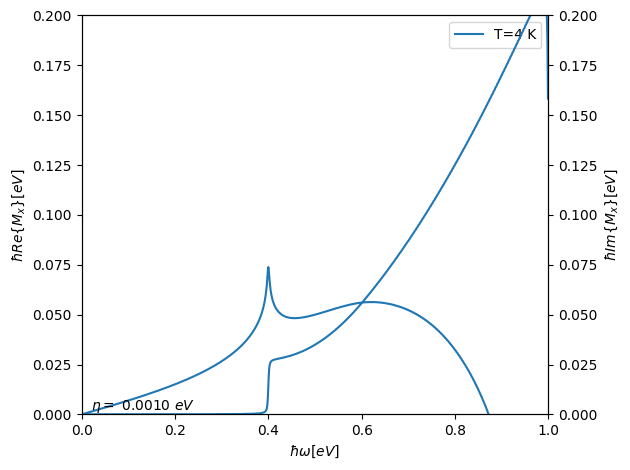

In [67]:
fig, *axs = setup_plot(x_lim=[0, 1], y_lim=[0, 0.2])
integrals = calculate_integral_points(
    mem_fn_op, ss_sum_real, ss_sum_imag, hbar_w_op, T=T_0
)
arrays_to_csv(
    np.array(ws_0.to("cpu")),
    np.array(integrals[0]),
    f"op, real, T={T_0}K, eta={eta_0}eV",
)
arrays_to_csv(
    np.array(ws_0.to("cpu")),
    list(np.array(integrals[1])),
    f"op, imag, T={T_0}K, eta={eta_0}eV",
)
plot_real_and_imag_result(*axs, *integrals, T=T_0)
axs[0].legend(loc="best")
fig.tight_layout()

### Analitički

In [51]:
def mem_fn_imag_anal(hbar_w, e_c, hbar_w_ph=hbar_w_op, u=Ef):
    faktor = a**3 * G_op2 * vf / (2 * pi * hbar**4 * vf**4)
    e_l = u - hbar_w_ph
    e_r = u + hbar_w_ph
    return (
        faktor
        * hbar  ## pomnoži s hbar da bude u istim jedinicama kao numerika
        * torch.where(hbar_w > hbar_w_ph, 1, 0)
        * (
            (hbar_w + e_l) ** 2 * torch.where(e_c > hbar_w + e_l, 1, 0)
            + (hbar_w - e_r) ** 2 * torch.where(e_r > hbar_w, 1, 0)
        )
    )


def mem_fn_real_anal(hbar_w, e_c, hbar_w_ph=hbar_w_op, u=Ef):
    faktor = a**3 * G_op2 * vf / (2 * pi**2 * hbar**4 * vf**4)
    e_l = u - hbar_w_ph
    e_r = u + hbar_w_ph
    return (
        faktor
        * hbar  ## pomnoži s hbar da bude u istim jedinicama kao numerika
        * (
            (hbar_w + e_l) ** 2
            * torch.log(torch.abs((hbar_w + e_l - e_c) / (hbar_w - hbar_w_ph)))
            - (hbar_w - e_l) ** 2
            * torch.log(torch.abs((hbar_w - e_l + e_c) / (hbar_w + hbar_w_ph)))
            - (hbar_w + e_r) ** 2
            * torch.log(torch.abs((hbar_w + e_r) / (hbar_w + hbar_w_ph)))
            + (hbar_w - e_r) ** 2
            * torch.log(torch.abs((hbar_w - e_r) / (hbar_w - hbar_w_ph)))
            + 2 * e_c * hbar_w
        )
    )

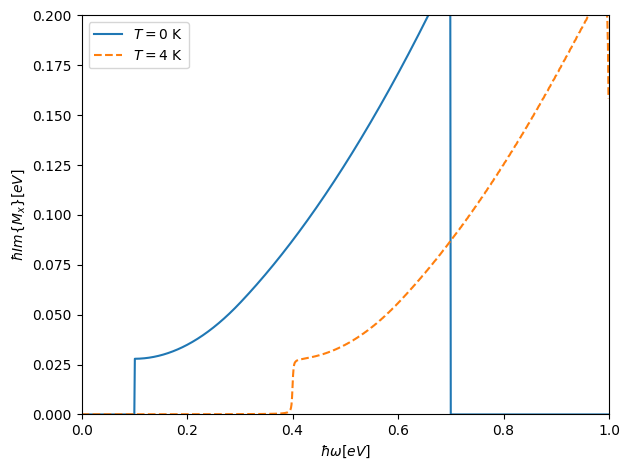

In [47]:
fig, ax = setup_plot(real=False, x_lim=[0, 1], y_lim=[0, 0.2])
values = list(mem_fn_imag_anal(ws_0, 0.8).to("cpu"))
plot_result(ax, values, T=0)
numeric_values = read_from_csv("op, imag, T=4K, eta=0.001eV")[1]
ax.plot(
    ws_0.to("cpu"),
    numeric_values,
    
    linestyle="--",
    label=f"$T={T_0}$ K",
)
ax.legend(loc="best")

fig.tight_layout()

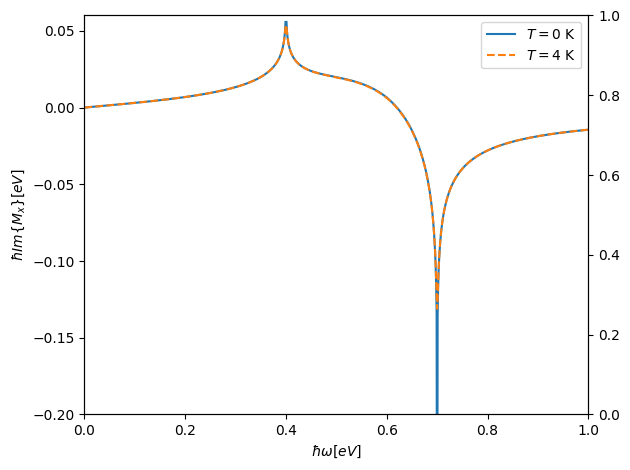

In [15]:
fig, ax = setup_plot(real=False, x_lim=[0, 1], y_lim=[-0.2, 0.06])
values = list(mem_fn_real_anal(ws_0, 0.5).to("cpu"))
plot_result(ax, values, T=0)
numeric_values = read_from_csv("op, real, T=4K, eta=0.001eV")[1]
ax.plot(
    ws_0.to("cpu"),
    numeric_values,
    linestyle="--",
    label=f"$T={T_0}$ K",
)
ax.legend(loc="best")
fig.tight_layout()

## Vodljvost

In [ ]:
def cond(hbar_w, mem_real, mem_imag, T):
    return (
        1j *hbar * e**2 * eff_concetration(T) / (hbar_w + mem_real + 1j * (mem_imag+eta_0))
    )/(1j *hbar * e**2 * eff_concetration(T) / (1j * (eta_0))).real

Text(0.5, 0, '$\\hbar \\omega [eV]$')

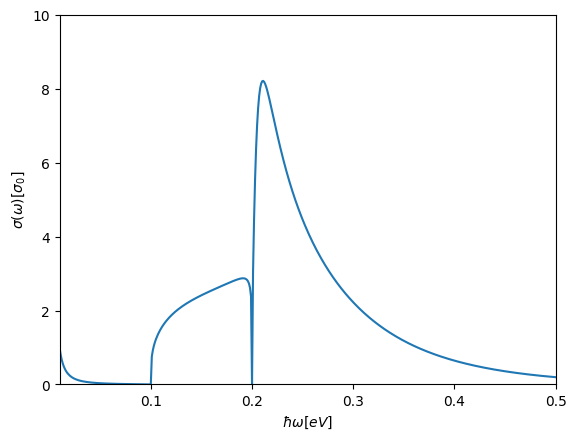

In [66]:
plt.plot(
    ws_0.to("cpu"),
    cond(
        ws_0.to("cpu"),
        mem_fn_real_anal(ws_0, 0.8, hbar_w_ph=0.1,u=0.7).to("cpu"),
        mem_fn_imag_anal(ws_0, 0.8, hbar_w_ph=0.1, u=0.7).to("cpu"),
        T=0,
    ).real,
)
plt.ylim([0, 10 ])

plt.xlim([0.01, 0.5])
plt.ylabel(r"$\sigma(\omega) [\sigma_0]$")
plt.xlabel(r"$\hbar \omega [eV]$")

## Različiti cutoffi i Fermijeve energije


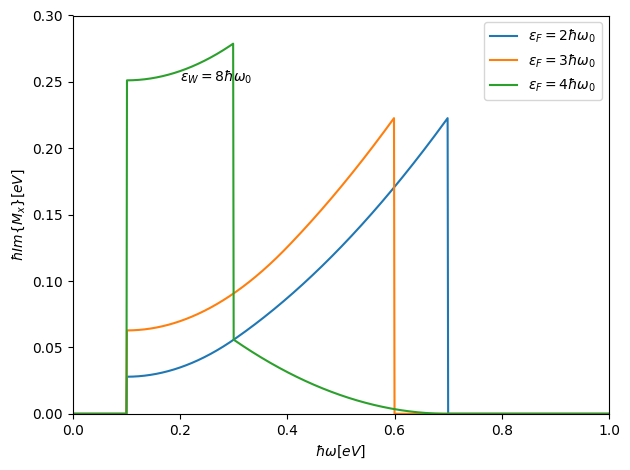

In [72]:
fig, ax = setup_plot(real=False, x_lim=[0, 1], y_lim=[-0.0005, 0.3])
values_1 = list(mem_fn_imag_anal(ws_0, 0.8, u=hbar_w_op*2).to("cpu"))
values_2 = list(mem_fn_imag_anal(ws_0, 0.8, u=hbar_w_op*3).to("cpu"))
values_3 = list(mem_fn_imag_anal(ws_0, 0.8, u=hbar_w_op*6).to("cpu"))
ax.plot(ws_0, values_1, label= r"$\varepsilon _F=2\hbar \omega_0$")
ax.plot(ws_0, values_2, label= r"$\varepsilon _F=3\hbar \omega_0$")
ax.plot(ws_0, values_3, label= r"$\varepsilon _F=4\hbar \omega_0$")
plt.text(0.2,0.25,r"$\varepsilon_W = 8\hbar\omega_0$")
ax.legend(loc="best")
fig.tight_layout()
fig.savefig("imag_ef.png", dpi=1200)

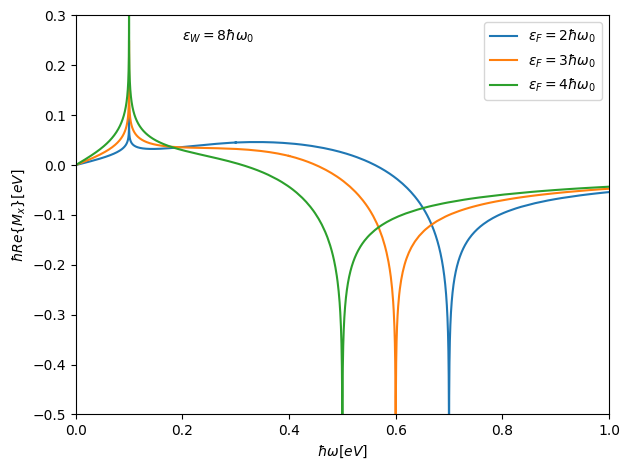

In [11]:
fig, ax = setup_plot(imag=False, x_lim=[0, 1], y_lim=[-0.5, 0.3])
values_1 = list(mem_fn_real_anal(ws_0, 0.8, u=hbar_w_op*2).to("cpu"))
values_2 = list(mem_fn_real_anal(ws_0, 0.8, u=hbar_w_op*3).to("cpu"))
values_3 = list(mem_fn_real_anal(ws_0, 0.8, u=hbar_w_op*4).to("cpu"))
ax.plot(ws_0, values_1, label= r"$\varepsilon _F=2\hbar \omega_0$")
ax.plot(ws_0, values_2, label= r"$\varepsilon _F=3\hbar \omega_0$")
ax.plot(ws_0, values_3, label= r"$\varepsilon _F=4\hbar \omega_0$")
plt.text(0.2,0.25,r"$\varepsilon_W = 8\hbar\omega_0$")
ax.legend(loc="best")
fig.tight_layout()
fig.savefig("real_ew.png", dpi=1200)

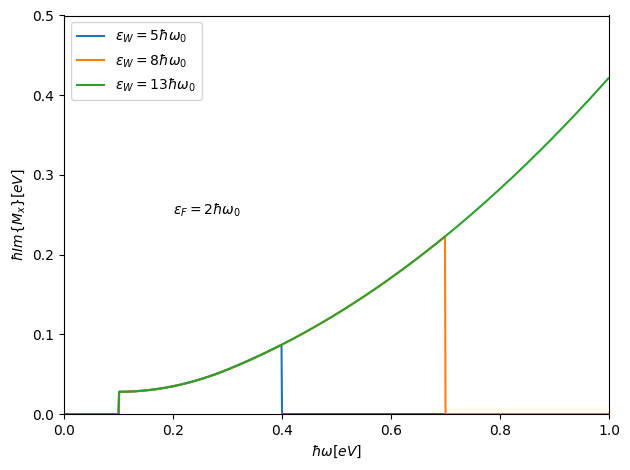

In [46]:
fig, ax = setup_plot(real=False, x_lim=[0, 1], y_lim=[-0.0005, 0.5])
values_1 = list(mem_fn_imag_anal(ws_0, e_c=hbar_w_op*5, u=hbar_w_op*2).to("cpu"))
values_2 = list(mem_fn_imag_anal(ws_0, e_c=hbar_w_op*8, u=hbar_w_op*2).to("cpu"))
values_3 = list(mem_fn_imag_anal(ws_0, e_c=hbar_w_op*13, u=hbar_w_op*2).to("cpu"))
ax.plot(ws_0, values_1, label= r"$\varepsilon _W=5\hbar \omega_0$")
ax.plot(ws_0, values_2, label= r"$\varepsilon _W=8\hbar \omega_0$")
ax.plot(ws_0, values_3, label= r"$\varepsilon _W=13\hbar \omega_0$")
plt.text(0.2,0.25,r"$\varepsilon_F = 2\hbar\omega_0$")
ax.legend(loc="best")
fig.tight_layout()

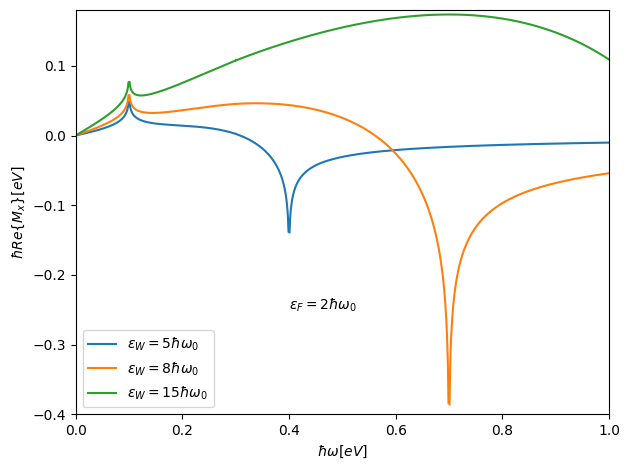

In [69]:
fig, ax = setup_plot(imag=False, x_lim=[0, 1], y_lim=[-0.4, 0.18])
values_1 = list(mem_fn_real_anal(ws_0, e_c=hbar_w_op*5, u=hbar_w_op*2).to("cpu"))
values_2 = list(mem_fn_real_anal(ws_0, e_c=hbar_w_op*8, u=hbar_w_op*2).to("cpu"))
values_3 = list(mem_fn_real_anal(ws_0, e_c=hbar_w_op*15, u=hbar_w_op*2).to("cpu"))
ax.plot(ws_0, values_1, label= r"$\varepsilon _W=5\hbar \omega_0$")
ax.plot(ws_0, values_2, label= r"$\varepsilon _W=8\hbar \omega_0$")
ax.plot(ws_0, values_3, label= r"$\varepsilon _W=15\hbar \omega_0$")
plt.text(0.4,-0.25,r"$\varepsilon_F = 2\hbar\omega_0$")
ax.legend(loc="best")
fig.tight_layout()
fig.savefig("real_ew.png", dpi=1200)

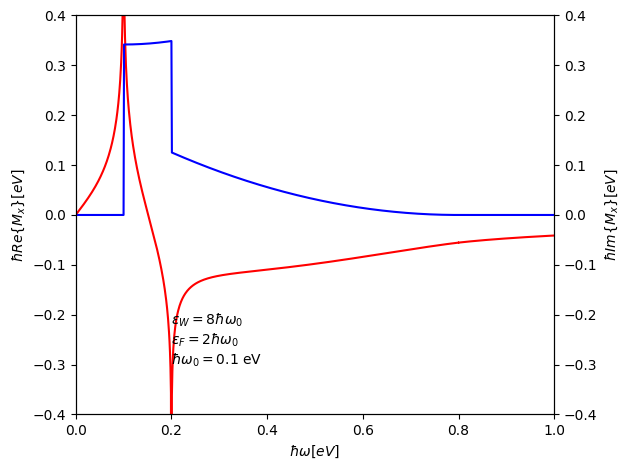

In [71]:
fig, ax1, ax2 = setup_plot(x_lim=[0, 1], y_lim=[-0.4, 0.4])
values_im = list(mem_fn_imag_anal(ws_0, e_c=hbar_w_op*8, u=hbar_w_op*7).to("cpu"))
values_re = list(mem_fn_real_anal(ws_0, e_c=hbar_w_op*8, u=hbar_w_op*7).to("cpu"))
ax2.plot(ws_0, values_im, linestyle="-", color="blue")
ax1.plot(ws_0, values_re, linestyle="-", color="red")
plt.text(0.2,-0.26,r"$\varepsilon_F = 2\hbar\omega_0$")
plt.text(0.2,-0.22,r"$\varepsilon_W = 8\hbar\omega_0$")
plt.text(0.2,-0.30,r"$\hbar\omega_0 = 0.1$ eV")
ax.legend(loc="best")
fig.tight_layout()
fig.savefig("imag_real.png", dpi=1200)